# Chapter 8e — Anthropogenic Warming: Temperature Records and the Global Carbon Budget

This notebook covers 11 scripts: `chap8_anthropogenic1a`-`1e`, `chap8_anthropogenic2`,
and `chap8_anthropogenic3a`-`3e`. Unlike `08a`-`08d` (first-principles physics
with no data), this group is entirely data-driven — it looks at the actual
observational record behind the models built so far: four independent
global surface-temperature datasets (OWID, HadCRUT, NOAA, FAOSTAT-derived
country-level trends) and the Global Carbon Budget's annual CO$_2$
emissions/sinks accounts.

**Real data used in this notebook** (all shipped as `.xlsx` in `hfs-archive`'s
own `Data/` folder, read directly with `pandas` rather than re-derived):
Our World in Data's temperature-anomaly series, the Met Office/UEA HadCRUT5
global and hemispheric series, NOAA's global/hemispheric land-ocean-index
series (monthly, aggregated to annual — see the note in section 1.4), the
FAOSTAT/FAO country-level annual surface-temperature-change series, and the
Global Carbon Project's Global Carbon Budget (fossil/land-use emissions,
natural sinks, atmospheric growth, and fuel-source breakdown).

**Scope decision (same as `07`):** `chap8_anthropogenic2` builds a country-
level choropleth map of warming trends in the source. As in Chapter 7, this
notebook builds the same information as ranked bar charts instead of an
actual map, since `plotly`+`kaleido` (the only map-rendering path available
here) requires downloading its own Chrome binary — confirmed unavailable in
`07`'s build — and `geopandas` would add a new heavy dependency used nowhere
else in the series.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

color_blue    = np.array([  0,  20, 255]) / 255
color_red     = np.array([255,  80,  50]) / 255
color_green   = np.array([ 20, 200,  80]) / 255
color_violet  = np.array([255,  51, 255]) / 255
color_teal    = np.array([ 56, 142, 142]) / 255
color_black   = np.array([0, 0, 0])
color_matlab  = np.array([0, 0.4470, 0.7410])
color_pink    = np.array([255, 105, 180]) / 255

def ols_trend(year, T, start_year, x_ols):
    # Simple OLS of T on [1, year] restricted to year >= start_year;
    # x_ols is the (separate) array of years the fitted line is drawn over.
    mask = year >= start_year
    x = year[mask].astype(float)
    y = T[mask].astype(float)
    beta1, beta0 = np.polyfit(x, y, 1)
    y_ols = beta0 + beta1 * x_ols
    return beta0, beta1, y_ols


## 1. Global and hemispheric temperature-anomaly records (`chap8_anthropogenic1a`-`1e`)

Four independent groups measure the global temperature anomaly from
slightly different station networks and baseline periods, but agree
closely once compared on a common baseline (section 1.5 below).


### 1.1 Our World in Data (`chap8_anthropogenic1a`)

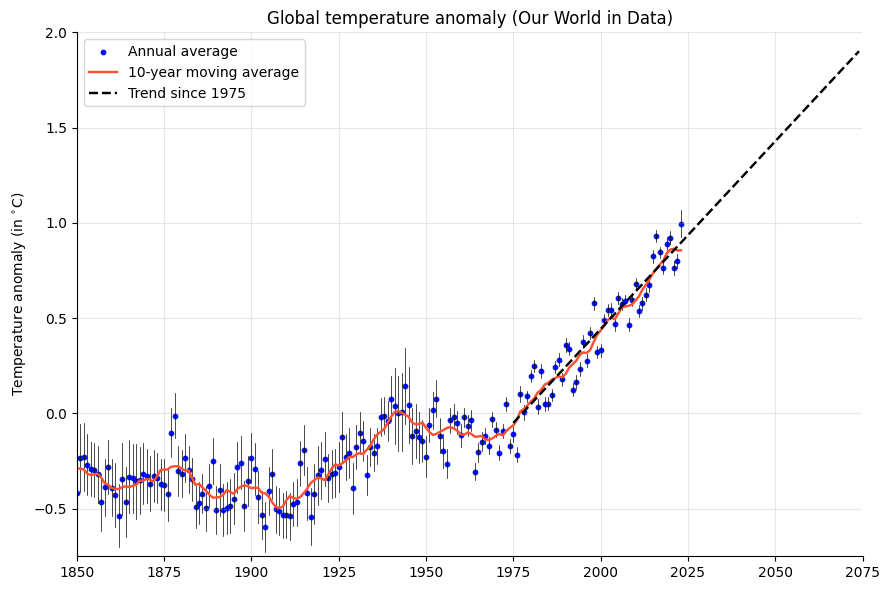

In [2]:

owid = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_OWID.xlsx")
owid = owid[owid["Entity"] == "Global"].sort_values("Year")
year = owid["Year"].to_numpy()
T = owid["Global average temperature anomaly relative to 1961-1990"].to_numpy()
T_lo = owid["Lower bound of the annual temperature anomaly (95% confidence interval)"].to_numpy()
T_hi = owid["Upper bound of the annual temperature anomaly (95% confidence interval)"].to_numpy()
Ts = pd.Series(T, index=year).rolling(10, center=True, min_periods=1).mean()

x_ols = np.arange(1975, 2075)
_, _, y_ols = ols_trend(year, T, 1975, x_ols)

fig, ax = plt.subplots(figsize=(9, 6))
for yr, lo, hi in zip(year, T_lo, T_hi):
    ax.plot([yr, yr], [lo, hi], "-", color=color_black, linewidth=0.5)
ax.scatter(year, T, s=10, color=color_blue, label="Annual average")
ax.plot(year, Ts.values, "-", color=color_red, linewidth=1.75, label="10-year moving average")
ax.plot(x_ols, y_ols, "--", color=color_black, linewidth=1.75, label="Trend since 1975")
ax.set_ylabel(r"Temperature anomaly (in $^{\circ}$C)")
ax.set_xlim(1850, 2075); ax.set_xticks(np.arange(1850, 2076, 25))
ax.set_ylim(-0.75, 2); ax.set_yticks(np.arange(-0.5, 2.01, 0.5))
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", fontsize=10)
ax.set_title("Global temperature anomaly (Our World in Data)")
plt.tight_layout()
plt.show()


### 1.2 HadCRUT5, global (`chap8_anthropogenic1b`)

Projected anomaly in 2050: +1.4336 C
Projected anomaly in 2075: +1.9288 C
Projected anomaly in 2100: +2.4239 C
Trend: +0.0198 C/year


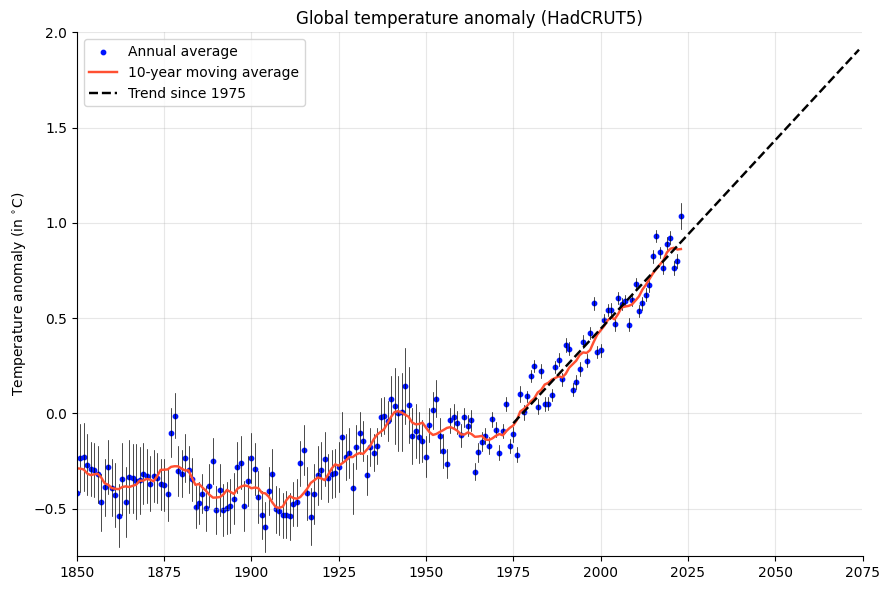

In [3]:

hadcrut_global = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_HadCRUT.xlsx", sheet_name="Global")
year = hadcrut_global["Time"].to_numpy()
T = hadcrut_global["Anomaly (deg C)"].to_numpy()
T_lo = hadcrut_global["Lower confidence limit (2.5%)"].to_numpy()
T_hi = hadcrut_global["Upper confidence limit (97.5%)"].to_numpy()
Ts = pd.Series(T, index=year).rolling(10, center=True, min_periods=1).mean()

x_ols = np.arange(1975, 2075)
beta0, beta1, y_ols = ols_trend(year, T, 1975, x_ols)
for target in (2050, 2075, 2100):
    print(f"Projected anomaly in {target}: {beta0 + beta1 * target:+.4f} C")
print(f"Trend: {beta1:+.4f} C/year")

fig, ax = plt.subplots(figsize=(9, 6))
for yr, lo, hi in zip(year, T_lo, T_hi):
    ax.plot([yr, yr], [lo, hi], "-", color=color_black, linewidth=0.5)
ax.scatter(year, T, s=10, color=color_blue, label="Annual average")
ax.plot(year, Ts.values, "-", color=color_red, linewidth=1.75, label="10-year moving average")
ax.plot(x_ols, y_ols, "--", color=color_black, linewidth=1.75, label="Trend since 1975")
ax.set_ylabel(r"Temperature anomaly (in $^{\circ}$C)")
ax.set_xlim(1850, 2075); ax.set_xticks(np.arange(1850, 2076, 25))
ax.set_ylim(-0.75, 2); ax.set_yticks(np.arange(-0.5, 2.01, 0.5))
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", fontsize=10)
ax.set_title("Global temperature anomaly (HadCRUT5)")
plt.tight_layout()
plt.show()


### 1.3 HadCRUT5, by hemisphere (`chap8_anthropogenic1c`)

Northern hemisphere: trend = +0.0278 C/year, 2100 projection = +3.3486 C
Southern hemisphere: trend = +0.0118 C/year, 2100 projection = +1.4992 C


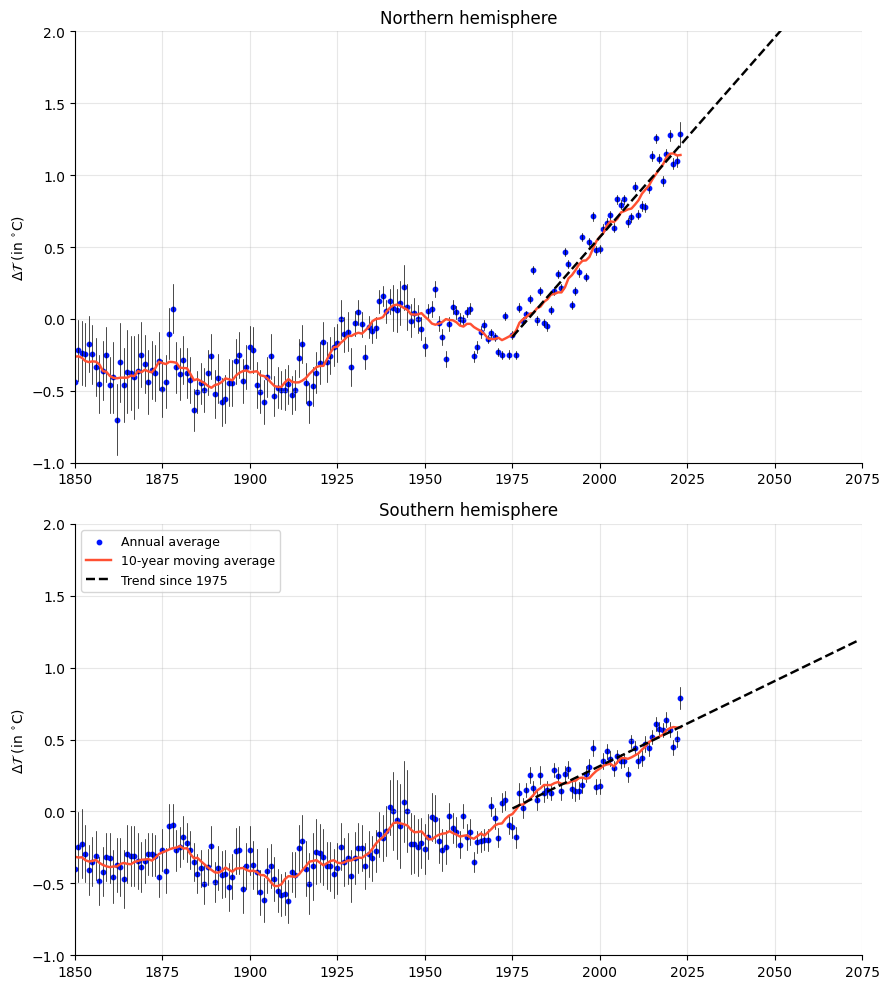

In [4]:

fig, axes = plt.subplots(2, 1, figsize=(9, 10))
for ax, sheet, title in zip(axes, ["Northern", "Southern"], ["Northern hemisphere", "Southern hemisphere"]):
    df = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_HadCRUT.xlsx", sheet_name=sheet)
    year = df["Time"].to_numpy()
    T = df["Anomaly (deg C)"].to_numpy()
    T_lo = df["Lower confidence limit (2.5%)"].to_numpy()
    T_hi = df["Upper confidence limit (97.5%)"].to_numpy()
    Ts = pd.Series(T, index=year).rolling(10, center=True, min_periods=1).mean()

    x_ols = np.arange(1975, 2075)
    beta0, beta1, y_ols = ols_trend(year, T, 1975, x_ols)
    print(f"{title}: trend = {beta1:+.4f} C/year, 2100 projection = {beta0 + beta1*2100:+.4f} C")

    for yr, lo, hi in zip(year, T_lo, T_hi):
        ax.plot([yr, yr], [lo, hi], "-", color=color_black, linewidth=0.5)
    p1 = ax.scatter(year, T, s=10, color=color_blue, label="Annual average")
    p2, = ax.plot(year, Ts.values, "-", color=color_red, linewidth=1.75, label="10-year moving average")
    p3, = ax.plot(x_ols, y_ols, "--", color=color_black, linewidth=1.75, label="Trend since 1975")
    ax.set_ylabel(r"$\Delta\mathcal{T}$ (in $^{\circ}$C)")
    ax.set_title(title)
    ax.set_xlim(1850, 2075); ax.set_xticks(np.arange(1850, 2076, 25))
    ax.set_ylim(-1.0, 2); ax.set_yticks(np.arange(-1.0, 2.01, 0.5))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    if title == "Southern hemisphere":
        ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


### 1.4 NOAA, global and by hemisphere, land vs. ocean (`chap8_anthropogenic1d`)

NOAA's own shipped "Annual" spreadsheet only carries the **global** series;
the hemispheric breakdown is only available in the **monthly** sheet. This
notebook reconstructs the annual hemispheric series by averaging NOAA's
monthly data within each calendar year — cross-checked against NOAA's own
official annual Global figures (matches to within rounding, confirming the
aggregation is correct) before being used here for the Northern/Southern
panels that the annual sheet alone can't provide.


Global / Land and Ocean: trend = +0.0188 C/year, 2100 projection = +2.4164 C
Global / Land: trend = +0.0329 C/year, 2100 projection = +4.0749 C
Global / Ocean: trend = +0.0124 C/year, 2100 projection = +1.6698 C
Northern Hemisphere / Land and Ocean: trend = +0.0276 C/year, 2100 projection = +3.3894 C
Northern Hemisphere / Land: trend = +0.0393 C/year, 2100 projection = +4.8159 C
Northern Hemisphere / Ocean: trend = +0.0188 C/year, 2100 projection = +2.3128 C
Southern Hemisphere / Land and Ocean: trend = +0.0099 C/year, 2100 projection = +1.4423 C
Southern Hemisphere / Land: trend = +0.0182 C/year, 2100 projection = +2.3901 C
Southern Hemisphere / Ocean: trend = +0.0080 C/year, 2100 projection = +1.2209 C


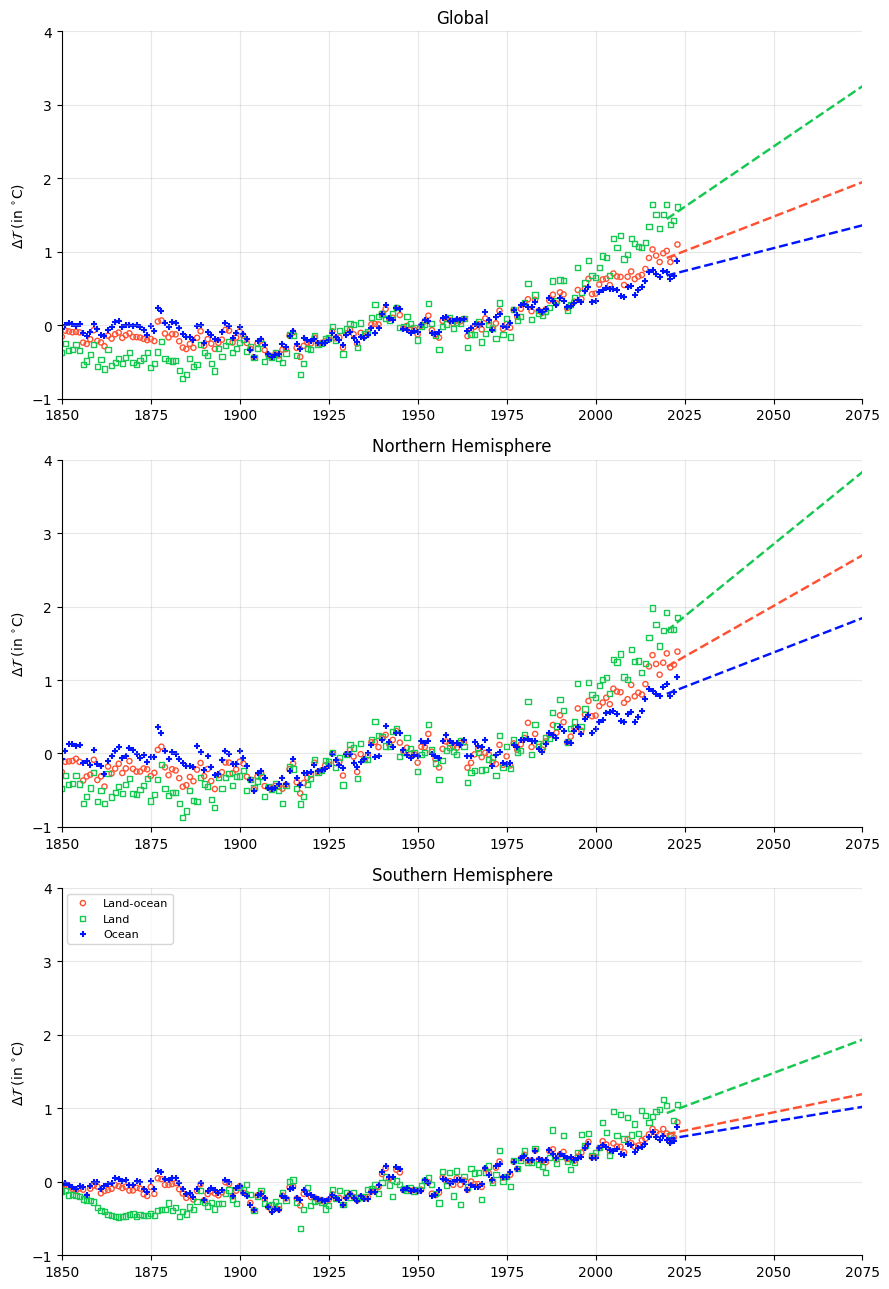

In [5]:

noaa_m = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_NOAA.xlsx",
                        sheet_name="1850-2023 Monthly NOAA Data", header=[3, 4])
noaa_m.columns = [f"{a}|{b}" for a, b in noaa_m.columns]
year_col = noaa_m.columns[0]
noaa_m["year"] = (noaa_m[year_col].astype(str).str[:4]).astype(int)
noaa_annual = noaa_m.groupby("year").mean(numeric_only=True)

regions = ["Global", "Northern Hemisphere", "Southern Hemisphere"]
series_names = ["Land and Ocean", "Land", "Ocean"]
colors3 = [color_red, color_green, color_blue]
markers3 = ["o", "s", "+"]

fig, axes = plt.subplots(3, 1, figsize=(9, 13))
year = noaa_annual.index.to_numpy()
cnd = year >= 1975
x_ols = np.arange(2020, 2120)

for ax, region in zip(axes, regions):
    handles = []
    for j, (sname, c, m) in enumerate(zip(series_names, colors3, markers3)):
        T = noaa_annual[f"{region}|{sname}"].to_numpy()
        beta0, beta1, y_ols = ols_trend(year, T, 1975, x_ols)
        print(f"{region} / {sname}: trend = {beta1:+.4f} C/year, 2100 projection = {beta0 + beta1*2100:+.4f} C")
        if m == "+":
            h = ax.scatter(year, T, s=14, color=c, marker=m, label=sname)
        else:
            h = ax.scatter(year, T, s=14, facecolors="none", edgecolors=c, marker=m, label=sname)
        ax.plot(x_ols, y_ols, "--", color=c, linewidth=1.75)
        handles.append(h)
    ax.set_ylabel(r"$\Delta\mathcal{T}$ (in $^{\circ}$C)", fontsize=10)
    ax.set_title(region, fontsize=12)
    ax.set_xlim(1850, 2075); ax.set_xticks(np.arange(1850, 2076, 25))
    ax.set_ylim(-1, 4); ax.set_yticks(np.arange(-1, 4.1, 1))
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    if region == "Southern Hemisphere":
        ax.legend(handles, ["Land-ocean", "Land", "Ocean"], loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


### 1.5 Cross-dataset comparison (`chap8_anthropogenic1e`)

No figure in the source script — just a correlation table across all six
NOAA/HadCRUT series, and their means over two standard climatological
baseline periods (1961-1990 and 1901-1999), to show how closely independent
measurement groups agree.


In [6]:

noaa_annual_trim = noaa_annual.loc[noaa_annual.index <= noaa_annual.index.max() - 0]
T1 = noaa_annual_trim[["Global|Land and Ocean", "Northern Hemisphere|Land and Ocean", "Southern Hemisphere|Land and Ocean"]].copy()
T1.columns = ["NOAA Global", "NOAA NH", "NOAA SH"]

had_global = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_HadCRUT.xlsx", sheet_name="Global").set_index("Time")["Anomaly (deg C)"]
had_nh = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_HadCRUT.xlsx", sheet_name="Northern").set_index("Time")["Anomaly (deg C)"]
had_sh = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_HadCRUT.xlsx", sheet_name="Southern").set_index("Time")["Anomaly (deg C)"]
T2 = pd.DataFrame({"HadCRUT Global": had_nh.index.map(lambda y: had_global.get(y, np.nan))})
T2["HadCRUT Global"] = had_global.reindex(had_nh.index).values
T2["HadCRUT NH"] = had_nh.values
T2["HadCRUT SH"] = had_sh.reindex(had_nh.index).values
T2.index = had_nh.index

common_years = T1.index.intersection(T2.index)
T1c = T1.loc[common_years]
T2c = T2.loc[common_years]
combined = pd.concat([T1c, T2c], axis=1)

print("Correlation matrix (%):")
display((100 * combined.corr()).round(2))

for lo, hi, label in [(1961, 1990, "1961-1990 baseline mean"), (1901, 1999, "1901-1999 baseline mean")]:
    mask = (combined.index >= lo) & (combined.index <= hi)
    print(f"\n{label}:")
    display(combined.loc[mask].mean().round(4).to_frame("mean anomaly (C)"))


Correlation matrix (%):


,NOAA Global,NOAA NH,NOAA SH,HadCRUT Global,HadCRUT NH,HadCRUT SH
NOAA Global,100.00,98.68,96.80,99.08,97.49,97.45
NOAA NH,98.68,100.00,91.48,98.69,99.30,93.91
NOAA SH,96.80,91.48,100.00,94.51,89.58,97.84
HadCRUT Global,99.08,98.69,94.51,100.00,98.87,97.66
HadCRUT NH,97.49,99.30,89.58,98.87,100.00,93.35
HadCRUT SH,97.45,93.91,97.84,97.66,93.35,100.00



1961-1990 baseline mean:


,mean anomaly (C)
NOAA Global,0.1320
NOAA NH,0.0864
NOAA SH,0.1772
HadCRUT Global,0.0077
HadCRUT NH,0.0010
HadCRUT SH,0.0144



1901-1999 baseline mean:


,mean anomaly (C)
NOAA Global,-0.0044
NOAA NH,-0.0053
NOAA SH,-0.0035
HadCRUT Global,-0.1063
HadCRUT NH,-0.0631
HadCRUT SH,-0.1496


## 2. Country-level warming trends (`chap8_anthropogenic2`)

Same OLS-trend-since-1975 methodology as section 1, applied independently
to each of 225 FAOSTAT-tracked countries/territories (skipping any country
with fewer than 30 valid annual observations since 1975, matching the
source script's own cutoff), to see which parts of the world are warming
fastest.


In [7]:

fao = pd.read_excel("../../data/chap8_anthropogenic_temperature_anomaly_FAOSTAT.xlsx")
year_cols = [c for c in fao.columns if c.startswith("F") and c[1:].isdigit()]
years = np.array([int(c[1:]) for c in year_cols])

records = []
for _, row in fao.iterrows():
    T = row[year_cols].to_numpy(dtype=float)
    mask = (years >= 1975) & ~np.isnan(T)
    if mask.sum() <= 30:
        continue
    x, y = years[mask].astype(float), T[mask]
    beta1, beta0 = np.polyfit(x, y, 1)
    tail = T[-5:]
    recent_mean = np.nanmean(tail) if np.any(~np.isnan(tail)) else np.nan
    records.append({
        "country": row["Country"],
        "recent_mean": recent_mean,
        "trend_per_year": beta1,
        "proj_2100": beta0 + beta1 * 2100,
    })

trend_df = pd.DataFrame(records).sort_values("trend_per_year", ascending=False)
print(f"{len(trend_df)} of {len(fao)} countries had a usable post-1975 trend.")
display(trend_df.head(10))
display(trend_df.tail(10))


206 of 225 countries had a usable post-1975 trend.


,country,recent_mean,trend_per_year,proj_2100
190,Ukraine,2.2008,0.068398,7.634271
123,"Moldova, Rep. of",2.2100,0.068260,7.577709
13,"Azerbaijan, Rep. of",2.0786,0.067660,7.415033
9,"Armenia, Rep. of",2.0758,0.065084,7.150316
67,Georgia,1.8858,0.064254,6.947136
154,Russian Federation,2.3632,0.059560,7.048700
72,Greenland,1.6618,0.058174,6.515993
18,"Belarus, Rep. of",2.4382,0.057332,6.843572
62,Finland,2.1852,0.055106,6.607795
58,"Estonia, Rep. of",2.4768,0.054030,6.580356


,country,recent_mean,trend_per_year,proj_2100
42,"Comoros, Union of the",0.8404,0.015635,1.958668
8,Argentina,0.8870,0.015529,1.991398
195,Uruguay,0.8048,0.014517,1.956085
138,Norfolk Island,0.7820,0.014375,1.755807
130,Namibia,0.7424,0.012281,1.789434
37,Chile,0.6904,0.011468,1.515208
45,Cook Islands,0.3558,0.008946,1.096879
24,Botswana,0.2044,0.005036,0.799384
205,Zimbabwe,0.2304,0.003682,0.636035
148,Pitcairn Islands,NaN,0.000729,-0.085812


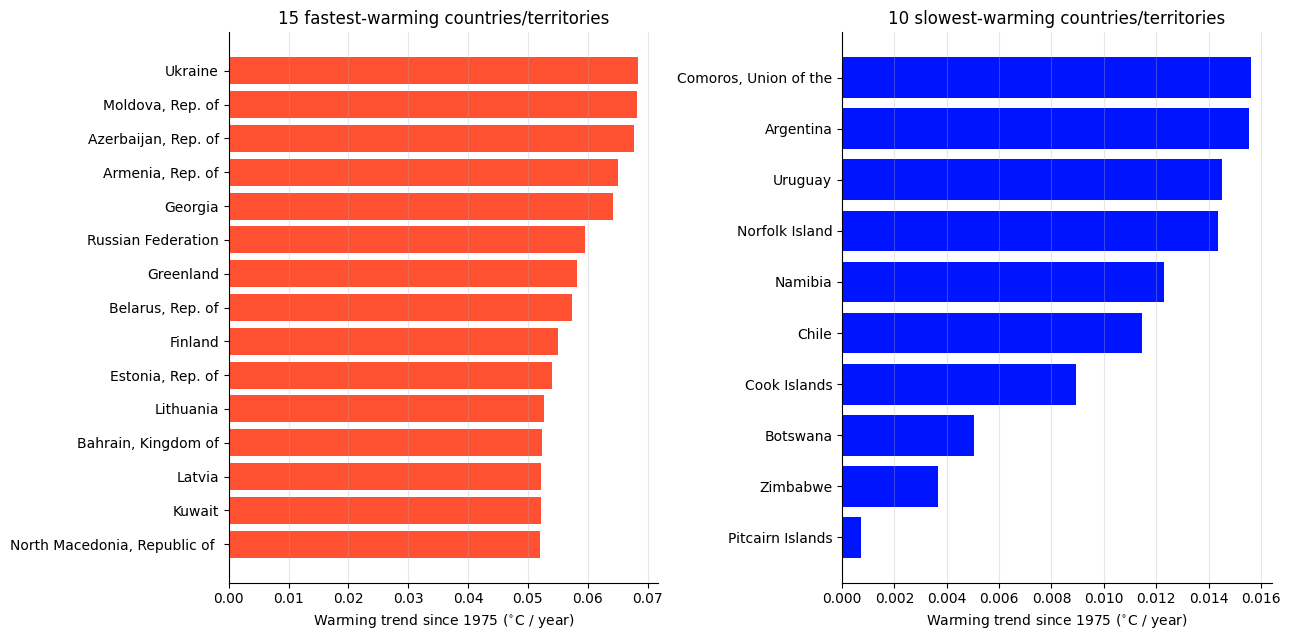

In [8]:

top15 = trend_df.head(15).iloc[::-1]
bottom10 = trend_df.tail(10).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
axes[0].barh(top15["country"], top15["trend_per_year"], color=color_red)
axes[0].set_xlabel(r"Warming trend since 1975 ($^{\circ}$C / year)")
axes[0].set_title("15 fastest-warming countries/territories")

axes[1].barh(bottom10["country"], bottom10["trend_per_year"], color=color_blue)
axes[1].set_xlabel(r"Warming trend since 1975 ($^{\circ}$C / year)")
axes[1].set_title("10 slowest-warming countries/territories")

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## 3. The Global Carbon Budget (`chap8_anthropogenic3a`-`3e`)

The Global Carbon Project's annual accounting of where anthropogenic
CO$_2$ comes from (fossil fuels, land-use change) and where it goes
(airborne, absorbed by the ocean, absorbed by land ecosystems), all in
GtCO$_2$/year (source data in MtCO$_2$/year, divided by 1000 throughout).


In [9]:

ghg = pd.read_excel("../../data/chap8_anthropogenic_ghg1.xlsx")
ghg = ghg[ghg["country"] == "World"].sort_values("year")
year = ghg["year"].to_numpy()

def z(col):
    v = ghg[col].to_numpy(dtype=float) / 1e3
    return np.where(v == 0, np.nan, v)


### 3.1 Annual emissions flows (`chap8_anthropogenic3a`)

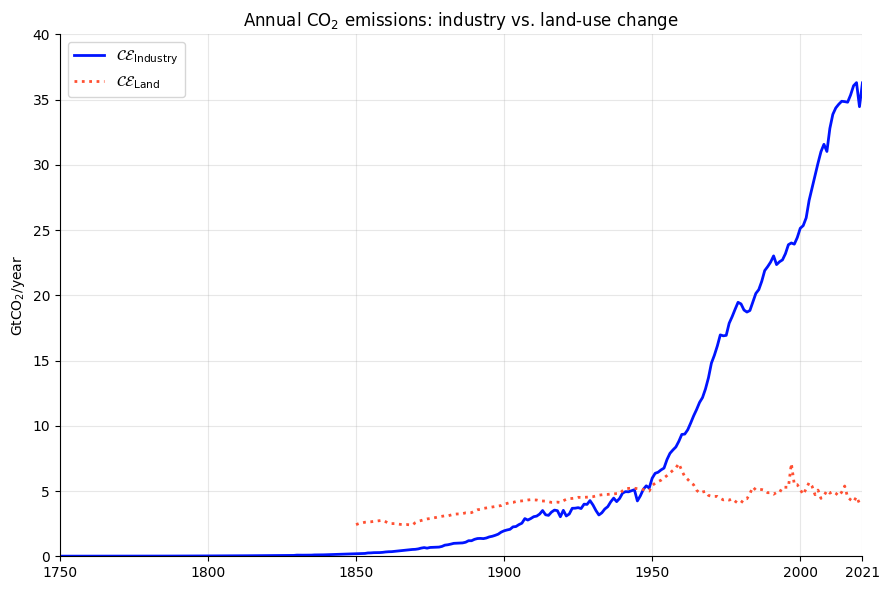

In [10]:

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(year, z("fossil_emissions_including_carbonation"), "-", color=color_blue, linewidth=2.0,
        label=r"$\mathcal{CE}_{\mathrm{Industry}}$")
ax.plot(year, z("land_use_change_emissions"), ":", color=color_red, linewidth=2.0,
        label=r"$\mathcal{CE}_{\mathrm{Land}}$")
ax.grid(True, alpha=0.3)
ax.set_xlim(1750, 2021); ax.set_xticks([1750, 1800, 1850, 1900, 1950, 2000, 2021])
ax.set_ylim(0, 40)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", fontsize=11)
ax.set_ylabel(r"GtCO$_2$/year")
ax.set_title("Annual CO$_2$ emissions: industry vs. land-use change")
plt.tight_layout()
plt.show()


### 3.2 Cumulative emissions and sinks (`chap8_anthropogenic3b`)

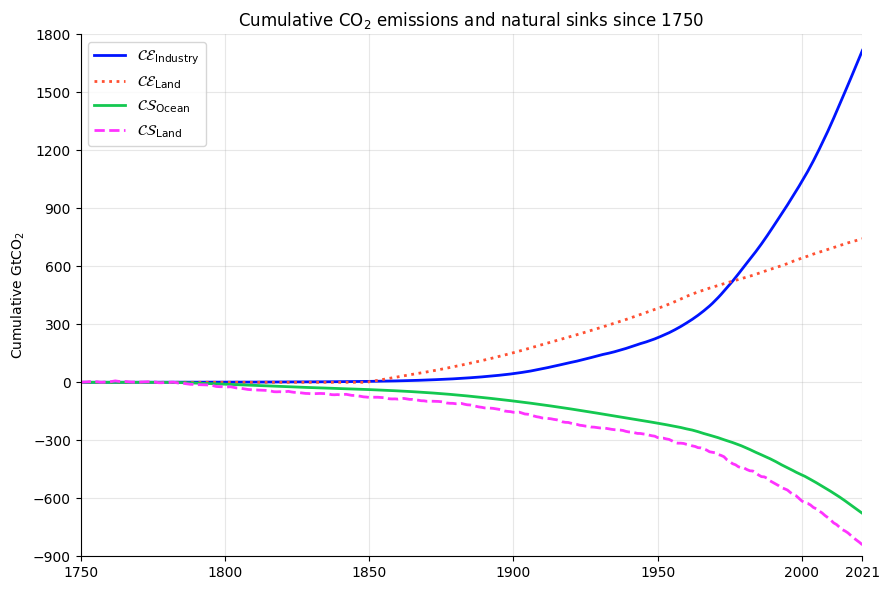

In [11]:

cum_fossil = np.nancumsum(z("fossil_emissions_including_carbonation"))
cum_land = np.nancumsum(z("land_use_change_emissions"))
cum_ocean = np.nancumsum(z("ocean_sink"))
cum_land_sink = np.nancumsum(z("land_sink"))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(year, cum_fossil, "-", color=color_blue, linewidth=2.0, label=r"$\mathcal{CE}_{\mathrm{Industry}}$")
ax.plot(year, cum_land, ":", color=color_red, linewidth=2.0, label=r"$\mathcal{CE}_{\mathrm{Land}}$")
ax.plot(year, -cum_ocean, "-", color=color_green, linewidth=2.0, label=r"$\mathcal{CS}_{\mathrm{Ocean}}$")
ax.plot(year, -cum_land_sink, "--", color=color_violet, linewidth=2.0, label=r"$\mathcal{CS}_{\mathrm{Land}}$")
ax.grid(True, alpha=0.3)
ax.set_xlim(1750, 2021); ax.set_xticks([1750, 1800, 1850, 1900, 1950, 2000, 2021])
ax.set_ylim(-900, 1800); ax.set_yticks(np.arange(-900, 1801, 300))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", fontsize=11)
ax.set_ylabel(r"Cumulative GtCO$_2$")
ax.set_title("Cumulative CO$_2$ emissions and natural sinks since 1750")
plt.tight_layout()
plt.show()


### 3.3 Cumulative atmospheric growth (`chap8_anthropogenic3c`)

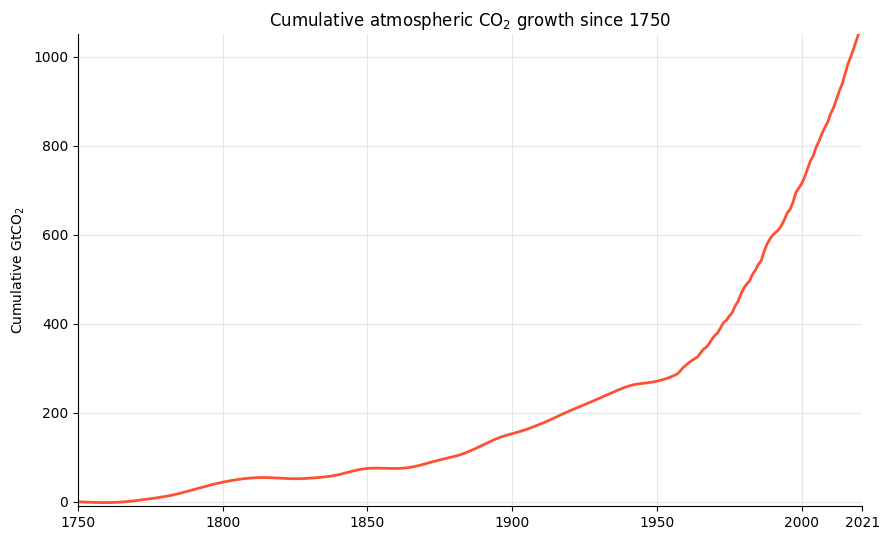

In [12]:

cum_growth = np.nancumsum(z("atmospheric_growth"))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(year, cum_growth, "-", color=color_red, linewidth=2.0)
ax.grid(True, alpha=0.3)
ax.set_xlim(1750, 2021); ax.set_xticks([1750, 1800, 1850, 1900, 1950, 2000, 2021])
ax.set_ylim(-10, 1050); ax.set_yticks(np.arange(0, 1101, 200))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_ylabel(r"Cumulative GtCO$_2$")
ax.set_title("Cumulative atmospheric CO$_2$ growth since 1750")
plt.tight_layout()
plt.show()


### 3.4 Budget summary at the most recent year (`chap8_anthropogenic3d`)

In [13]:

latest = ghg.iloc[-1]
latest_year = int(latest["year"])

flow_cols = ["fossil_emissions_excluding_carbonation", "land_use_change_emissions",
             "atmospheric_growth", "ocean_sink", "land_sink", "cement_carbonation_sink",
             "budget_imbalance"]
flow_table = pd.DataFrame({"GtCO2/year": (latest[flow_cols].astype(float) / 1e3).round(2)})
print(f"Global Carbon Budget, {latest_year} (GtCO2/year):")
display(flow_table)

fossil_inc = latest["fossil_emissions_including_carbonation"] / 1e3
land_use = latest["land_use_change_emissions"] / 1e3
total = fossil_inc + land_use
ocean = latest["ocean_sink"] / 1e3
land_sink = latest["land_sink"] / 1e3
growth = latest["atmospheric_growth"] / 1e3
share_table = pd.DataFrame({
    "value": [fossil_inc, land_use, total, 100 * ocean / total, 100 * land_sink / total, 100 * growth / total]
}, index=["Fossil (GtCO2)", "Land-use (GtCO2)", "Total emissions (GtCO2)",
          "Ocean sink (% of total)", "Land sink (% of total)", "Atmospheric growth (% of total)"])
display(share_table.round(2))

cum_fossil_end = cum_fossil[-1]
cum_land_end = cum_land[-1]
cum_growth_end = cum_growth[-1]
airborne_fraction = cum_growth_end / (cum_fossil_end + cum_land_end)
print(f"\nCumulative airborne fraction since 1750: {100*airborne_fraction:.2f}%")


Global Carbon Budget, 2021 (GtCO2/year):


,GtCO2/year
fossil_emissions_excluding_carbonation,37.12
land_use_change_emissions,3.94
atmospheric_growth,19.14
ocean_sink,10.55
land_sink,12.64
cement_carbonation_sink,0.84
budget_imbalance,-2.12


,value
Fossil (GtCO2),36.28
Land-use (GtCO2),3.94
Total emissions (GtCO2),40.22
Ocean sink (% of total),26.23
Land sink (% of total),31.43
Atmospheric growth (% of total),47.60



Cumulative airborne fraction since 1750: 43.74%


### 3.5 Emissions by fossil-fuel source (`chap8_anthropogenic3e`)

The stacked area chart below shows each source's share of **cumulative**
emissions since 1850 — i.e. at each year, what fraction of all the CO$_2$
emitted *so far* came from coal vs. oil vs. gas, etc. This is why coal's
share declines smoothly over time even though its annual emissions keep
rising: oil and gas didn't scale up until the 20th century, so their
cumulative share is still "catching up".


Share of ANNUAL emissions by source, at selected years (%):


,Coal,Oil,Gas,Cement,Flaring,Other
1850,100.00,0.00,0.00,0.00,0.00,0.00
1900,95.85,3.55,0.60,0.00,0.00,0.00
1950,65.10,26.79,6.09,1.13,0.81,0.08
1975,34.74,47.64,13.17,1.99,2.18,0.29
2000,36.18,40.42,18.61,2.87,1.05,0.86
2020,40.11,33.23,20.38,4.33,1.12,0.83


Share of CUMULATIVE emissions by source, at selected years (%):


,Coal,Oil,Gas,Cement,Flaring,Other
1850,100.00,0.00,0.00,0.00,0.00,0.00
1900,97.58,2.05,0.37,0.00,0.00,0.00
1950,85.24,12.13,2.15,0.40,0.03,0.06
1975,63.49,27.43,6.88,1.17,0.87,0.16
2000,50.00,35.10,11.72,1.77,1.03,0.39
2020,46.29,35.02,14.52,2.56,1.06,0.55


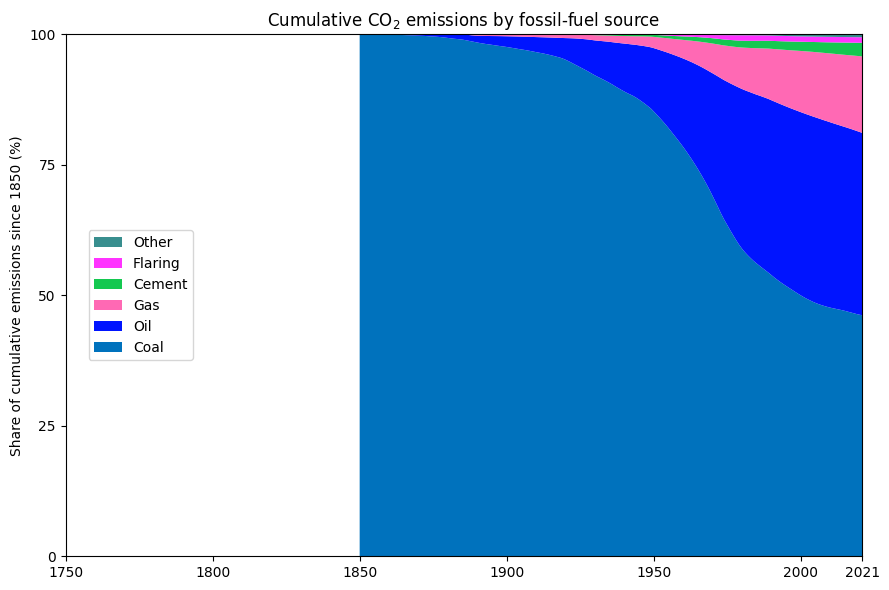

In [14]:

ghg1850 = ghg[ghg["year"] >= 1850].copy()
year2 = ghg1850["year"].to_numpy()
sources = ["coal", "oil", "gas", "cement", "flaring", "other"]
labels = ["Coal", "Oil", "Gas", "Cement", "Flaring", "Other"]
data = ghg1850[sources].to_numpy(dtype=float)
data = np.where(np.isnan(data), 0.0, data) / 1e3
cum_data = np.cumsum(data, axis=0)

selected_years = [1850, 1900, 1950, 1975, 2000, 2020]
annual_share_rows, cum_share_rows = [], []
for k, sy in enumerate(selected_years):
    idx = np.searchsorted(year2, sy)
    if k == 0:
        window = slice(idx, idx + 5)
    elif k == len(selected_years) - 1:
        window = slice(idx - 4, idx + 1)
    else:
        window = slice(idx - 2, idx + 3)
    avg = data[window].mean(axis=0)
    annual_share_rows.append(100 * avg / avg.sum())
    cshare = cum_data[idx]
    cum_share_rows.append(100 * cshare / cshare.sum())

annual_share_df = pd.DataFrame(annual_share_rows, index=selected_years, columns=labels).round(2)
cum_share_df = pd.DataFrame(cum_share_rows, index=selected_years, columns=labels).round(2)
print("Share of ANNUAL emissions by source, at selected years (%):")
display(annual_share_df)
print("Share of CUMULATIVE emissions by source, at selected years (%):")
display(cum_share_df)

cum_share_series = 100 * cum_data / cum_data.sum(axis=1, keepdims=True)
colors6 = [color_matlab, color_blue, color_pink, color_green, color_violet, color_teal]

fig, ax = plt.subplots(figsize=(9, 6))
ax.stackplot(year2, cum_share_series.T, labels=labels, colors=colors6)
ax.set_xlim(1850, 2021); ax.set_xticks([1750, 1800, 1850, 1900, 1950, 2000, 2021])
ax.set_ylim(0, 100); ax.set_yticks(np.arange(0, 101, 25))
handles, lbls = ax.get_legend_handles_labels()
ax.legend(handles[::-1], lbls[::-1], loc="center left", bbox_to_anchor=(0.02, 0.5), fontsize=10)
ax.set_ylabel("Share of cumulative emissions since 1850 (%)")
ax.set_title("Cumulative CO$_2$ emissions by fossil-fuel source")
plt.tight_layout()
plt.show()


## Summary

This notebook is the first data-driven checkpoint of Chapter 8: four
independent surface-temperature records (all agreeing on roughly
+1.0-1.3°C since the 1961-1990 baseline and correlating above 95% with
each other over their common period), a country-level breakdown of who is
warming fastest, and the Global Carbon Project's accounting of where
anthropogenic CO$_2$ comes from and where it currently goes (roughly half
of cumulative emissions have been absorbed by oceans and land ecosystems;
the rest remains airborne).

**Data-fidelity note:** NOAA's hemispheric annual series (used in section
1.4) isn't shipped as a standalone annual file — it was reconstructed by
averaging NOAA's monthly data within each year, cross-checked against
NOAA's own official annual Global figures before use (see the markdown
note above section 1.4).

**Scope decision (consistent with Chapter 7):** section 2's country-level
map was built as ranked bar charts rather than an actual choropleth, for
the same `plotly`/`kaleido`-needs-Chrome reason documented in `07`.

No new packaging candidates from this notebook — the `ols_trend` helper
and the fuel-source cumulative-share computation are both tied to this
notebook's specific dataset layouts, not generic primitives.
